Tutorial from [link](https://pertpy.readthedocs.io/en/latest/tutorials/notebooks/sccoda.html)

Install Jax for 
```bash
pyenv virtualenv 3.11.8 scoda-gpu
pyenv activate scoda-gpu
pip install --upgrade "jax[cuda12_local]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
pip uninstall -y jax jaxlib jax-cuda12-plugin
pip install jax==0.4.31 jaxlib==0.4.31+cuda12.cudnn89 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
pip install scvi-tools pertpy scanpy pandas matplotlib seaborn
pip install jupyter ipykernel
python -m ipykernel install --user --name=scoda-gpu --display-name="scCODA GPU"
```


Resutls depends on:
- reference cell type
    - choose vy me
    - autamtically picked
- level of granularity in cell type annotation
- Covariates in formula

In [1]:
# import os
# os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.2/targets/x86_64-linux/lib:' + os.environ.get('LD_LIBRARY_PATH', '')
# os.environ['CUDA_HOME'] = '/usr/local/cuda-12.2'
# import jax
# print('Backend:', jax.default_backend())
# print('Devices:', jax.devices())

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import json

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

ADATA = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_QCed_labelled_zoned.h5ad"
SAVE_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional"
NUTS_ITERATIONS=5000

MAPPING_CELL_TYPE_JSON = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"
# Covariates to use for stat test
COV_TO_BRING_TO_AGGREGATED_VERSION = [CONTRAST_VARIABLE, "sex", SAMPLE_VARIABLE]


FORMULA = f"C({CONTRAST_VARIABLE}, Treatment('{CONTRAST_BASELINE}')) + sex"
FORMULA

"C(condition, Treatment('Control')) + sex"

In [2]:
!export LD_LIBRARY_PATH=/usr/local/cuda-12.2/targets/x86_64-linux/lib:$LD_LIBRARY_PATH
!export CUDA_HOME=/usr/local/cuda-12.2
# export XLA_PYTHON_CLIENT_PREALLOCATE=false
# export XLA_PYTHON_CLIENT_MEM_FRACTION=0.5

In [3]:
os.environ['JAX_PLATFORMS'] = 'cuda'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # Don't preallocate all GPU memory
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'  # Use up to 90% of GPU memory

import jax
import jax.numpy as jnp
import pertpy as pt

print("Backend:", jax.default_backend())  # Must be 'gpu'
print("Devices:", jax.devices())

# Simple GPU test
x = jnp.ones((10, 10))
result = jnp.sum(x @ x.T)
print("GPU compute works:", result)

Backend: gpu
Devices: [CudaDevice(id=0)]
GPU compute works: 1000.0


# Define specific annotations for cell level

In [4]:
adata = sc.read_h5ad(ADATA, backed="r")

In [8]:
adata#.obs.Neighborhood_name.unique()

AnnData object with n_obs × n_vars = 502456 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_QCed_labelled_zoned.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_prob

# Analyse

In [5]:
def run_scCODA(adata, CT_COL, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, print_summary=False, NUTS_ITERATIONS=5000):

    # initialise
    sccoda = pt.tl.Sccoda()

    # Create sample level counts (sort of pseudobulikng)
        # Y matrix --> (N×K) - cell counts per sample
    mdata = sccoda.load(
        adata,
        type="cell_level", #cell_level --> each row of adat is a cell
        generate_sample_level=True,
        cell_type_identifier=CT_COL, # cell type col
        sample_identifier=SAMPLE_VARIABLE, #Each unique value = one biological replicate
        covariate_obs=COV_TO_BRING_TO_AGGREGATED_VERSION, #  "Which metadata do I want to preserve?" (only if all cells have same value it is taken)
        #levels_orig=[CONTRAST_BASELINE, CONTRAST_STIM],
        modality_key_1="coda"
    )
    print(mdata)

    #     # 🔍 DIAGNOSTIC: Check for missing values
    # print(f"\nSample-level data shape: {mdata['coda'].shape}")
    # print(f"\nMissing values in covariates:")
    # for cov in COV_TO_BRING_TO_AGGREGATED_VERSION:
    #     n_missing = mdata['coda'].obs[cov].isna().sum()
    #     if n_missing > 0:
    #         print(f"  {cov}: {n_missing} missing")
    #         print(f"    Samples with missing {cov}:")
    #         print(f"    {mdata['coda'].obs[mdata['coda'].obs[cov].isna()].index.tolist()}")
    

    ###########################################################

    proportions_plot = sccoda.plot_boxplots(mdata, feature_name=CONTRAST_VARIABLE, add_dots=False, figsize=(20,5), return_fig=True)
    #plt.show()

    ###########################################################

    # Set up statical mdole
    # Creates the X matrix (N×M)
    # Selects reference cell type (sets β_ref = 0)
    mdata = sccoda.prepare(
        mdata,
        formula=FORMULA, 
        reference_cell_type=REFERENCE_CT,
        automatic_reference_absence_threshold=0.01, 
            #Maximum fraction of samples where cell type can be absent
            # Why: Prevents rare cell types from being selected as reference
    )
    # Check which reference was selected:
    print(f"Selected reference: {mdata['coda'].uns['scCODA_params']['reference_cell_type']}")

    ###########################################################

    # Run HMC Sampling ..>  #  (NUTS = No-U-Turn Sampler, an improved HMC)
    sccoda.run_nuts(
        mdata,
        num_warmup=500, 
        num_samples=NUTS_ITERATIONS, # posterior samples to keep
            # final soluton (betas) are mean of each sample. i cna estimate the variance. and porb=hwp poften b!=0
        rng_key=42, # seed
    )

    ###########################################################

    if print_summary:
        summary = sccoda.summary(mdata,extended=True)
        print(summary)

    ###########################################################

    # If there are no signficant effects --> impossibel to plot the barplot
    effects_df = sccoda.get_effect_df(mdata)
    nonzero = effects_df.query("`log2-fold change` != 0")

    if nonzero.shape[0] > 0:
        barplot = sccoda.plot_effects_barplot(
            mdata,
            covariates=[CONTRAST_VARIABLE],
            figsize=(5, 20),
            parameter="log2-fold change",
            return_fig=True,
        )
    else:
        print("All effects shrunk to zero — no barplot generated.")

    ###########################################################

    results = pd.DataFrame(sccoda.credible_effects(
        # P_inclusion(cell_type, constion) = number beta_constion > 0.001 / tot betas
        # which is a good thr for P_inclussion?
        # take thr that make the FDR selected
        mdata,
        est_fdr=0.05, # FDR step finds the optimal threshold of P_inclusion automatically
    )).rename(columns={"Final Parameter": "is_significant"})
    results = results.reset_index()
    results['Covariate'] = results["Covariate"].str.extract(r'\[T\.(.*?)\]')[0]
    #display(results)

    #intercept_df = sccoda.get_intercept_df(mdata)
    effect_df = sccoda.get_effect_df(mdata)
    effect_df = effect_df.reset_index()
    effect_df['Covariate'] = effect_df["Covariate"].str.extract(r'T\.(.*)$')[0]
    #display(effect_df)

    merged_df = effect_df.merge(
        results, 
        how='left',        
        validate="one_to_one"
    )

    display(merged_df[(merged_df["Covariate"] == CONTRAST_STIM) & (merged_df["is_significant"])])

    ###########################################################

    merged_df.to_csv(f"{save_folder}/results.csv", index=False)
    if nonzero.shape[0] > 0:
        barplot.savefig(f"{save_folder}/logFC_plot.png", bbox_inches='tight', dpi=300)
    proportions_plot.savefig(f"{save_folder}/proportions.png", bbox_inches='tight', dpi=300)  # Changed to .png

    return sccoda, mdata, merged_df

In [6]:
def run_scCODA_for_NucSeq_dataset(adata, subfolder_save, LEVELS_ANNOTATION, CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, SAMPLE_VARIABLE, SAVE_FOLDER, FORMULA, REFERENCE_CT, NUTS_ITERATIONS, tissue_col="tissue", ):

    df_list = []
    for tissue in adata.obs[tissue_col].unique().tolist():
        for level_annotation in LEVELS_ANNOTATION:

            print(tissue, level_annotation)

            # Samples that miss some vital info
            bad_samples = [i for cov in [CONTRAST_VARIABLE, *COV_TO_BRING_TO_AGGREGATED_VERSION] for i in adata.obs[adata.obs[cov].isna()][SAMPLE_VARIABLE].unique().tolist()]

            # Filter
            adata_sub = adata[
                    (adata.obs[tissue_col] == tissue) & 
                    (~ adata.obs[SAMPLE_VARIABLE].isin(bad_samples))
                ].to_memory().copy()
            print(adata_sub.obs[level_annotation].value_counts())
            
            # Save folder
            save_folder = f"{SAVE_FOLDER}/{subfolder_save}/{tissue}/{level_annotation}"
            os.makedirs(save_folder, exist_ok=True)

            sccoda, mdata, merged_df = run_scCODA(adata_sub, level_annotation, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, NUTS_ITERATIONS=NUTS_ITERATIONS)

            merged_df["tissue"] = tissue
            merged_df["annotation"] = level_annotation

            df_list.append(merged_df)        

        #     break
        # break

    df = pd.concat(df_list)
    df.to_csv(f"{SAVE_FOLDER}/{subfolder_save}/merged_df.csv", index=False)

    return df

# With All cells

In [7]:
REFERENCE_CT_ALL_CELLS = "automatic"
LEVELS_ANNOTATION_ALL_CELLS = ["Class_name", "Subclass_name", "Group_name", "spn_type", "spn_receptor_type"]

In [8]:
with open(MAPPING_CELL_TYPE_JSON, 'r') as f:
    classifications = json.load(f)

for cat in LEVELS_ANNOTATION_ALL_CELLS:
    if cat in adata.obs.columns:
        continue
    # fillna with ORIGINAL VALUES
    adata.obs[cat] = adata.obs["Group_name"].map(classifications[cat]).fillna(adata.obs["Group_name"])

In [ ]:
df_all_cells = run_scCODA_for_NucSeq_dataset(
    adata, 
    subfolder_save="all_cells", 
    LEVELS_ANNOTATION=LEVELS_ANNOTATION_ALL_CELLS, 
    CONTRAST_VARIABLE=CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION=COV_TO_BRING_TO_AGGREGATED_VERSION, 
    SAMPLE_VARIABLE=SAMPLE_VARIABLE, SAVE_FOLDER=SAVE_FOLDER, FORMULA=FORMULA, 
    REFERENCE_CT=REFERENCE_CT_ALL_CELLS, NUTS_ITERATIONS=NUTS_ITERATIONS,
    tissue_col="tissue",
)


DFC Class_name
MuData object with n_obs × n_vars = 44 × 12
  var:	'n_cells'
  1 modality
    coda:	44 x 12
      obs:	'donor_id', 'sex', 'condition'
      var:	'n_cells'

Sample-level data shape: (44, 12)

Missing values in covariates:


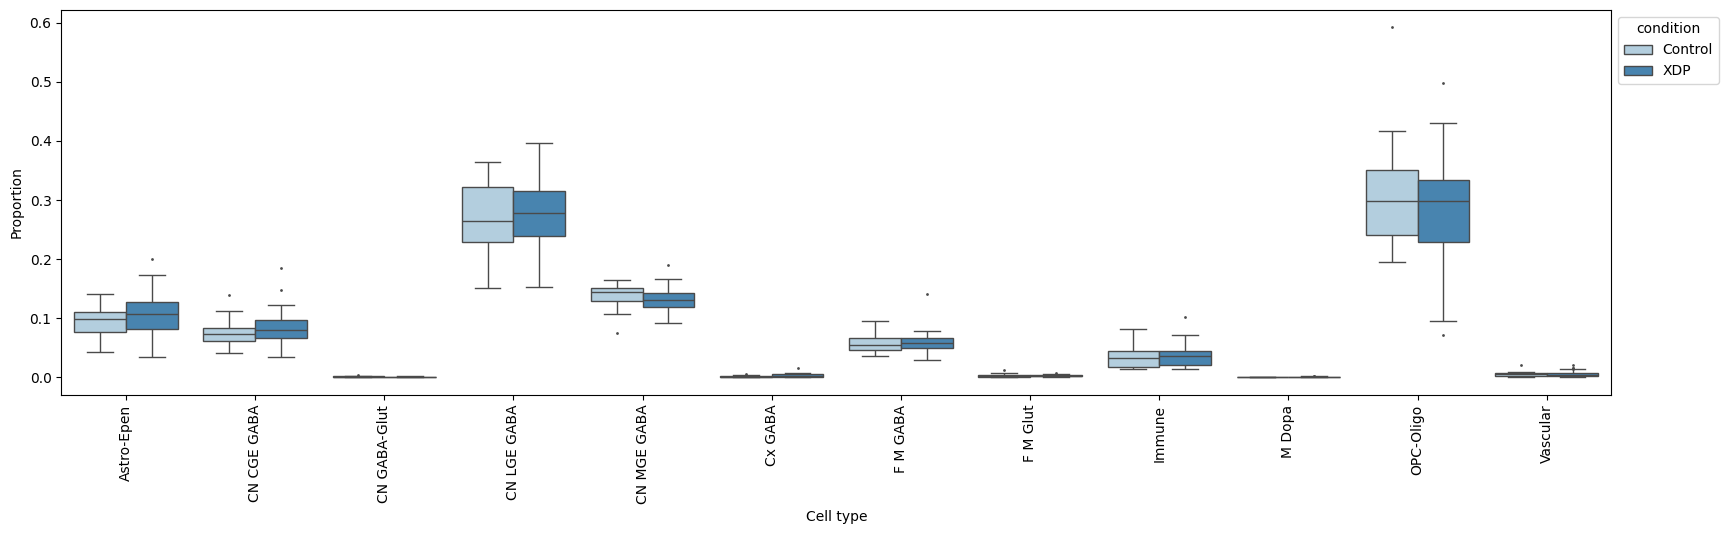

Selected reference: F M Glut


sample: 100%|██████████| 1500/1500 [03:26<00:00,  7.27it/s, 255 steps of size 1.40e-02. acc. prob=0.89]
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
10,XDP,OPC-Oligo,-0.271708,-0.431,-0.097,0.091,0.994,673.940728,-0.300875,True


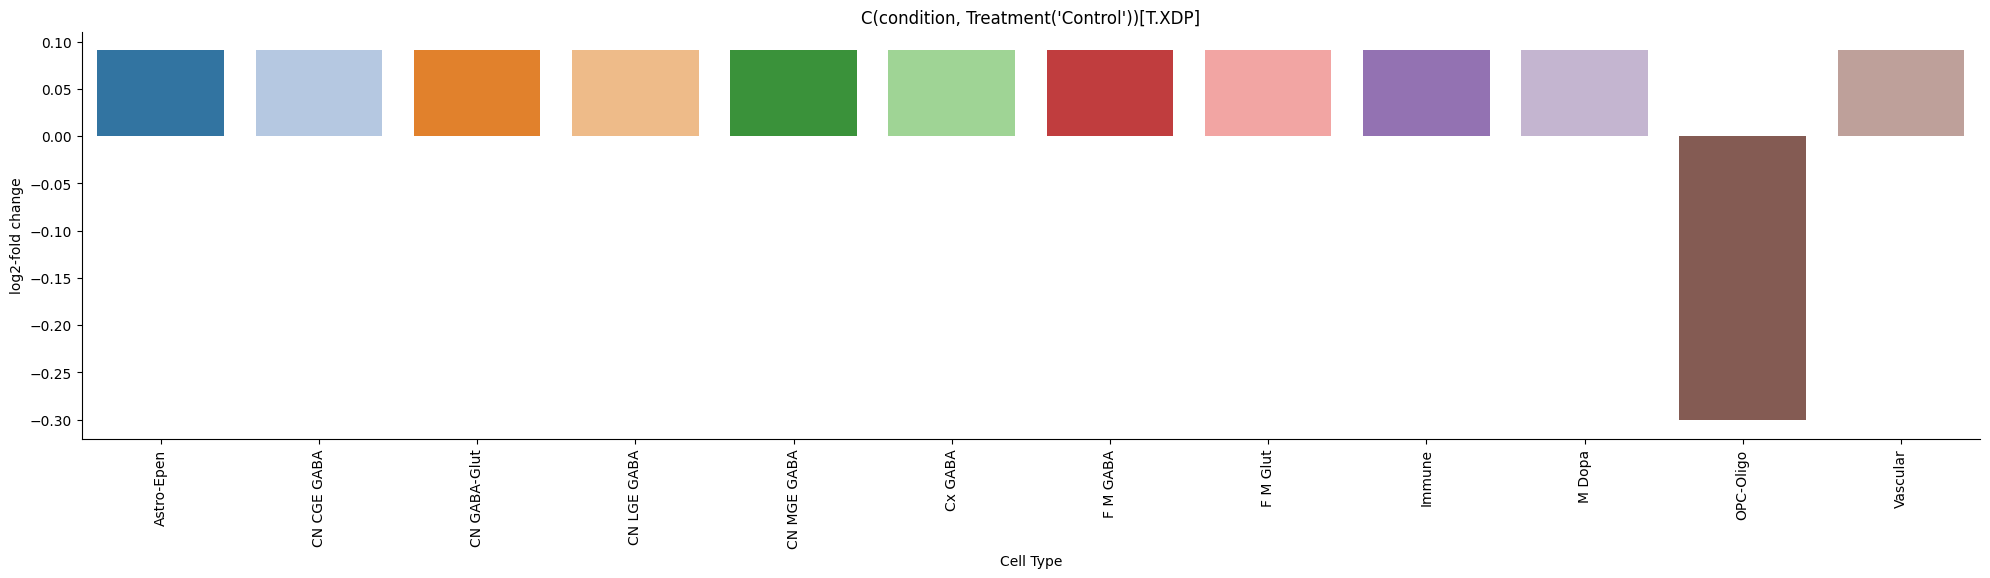

In [ ]:

# df_list = []
# for tissue in adata.obs.tissue.unique().tolist():
#     for level_annotation in LEVELS_ANNOTATION:

#         print(tissue, level_annotation)

#         # Samples that miss some vital info
#         bad_samples = [i for cov in [CONTRAST_VARIABLE, *COV_TO_BRING_TO_AGGREGATED_VERSION] for i in adata.obs[adata.obs[cov].isna()][SAMPLE_VARIABLE].unique().tolist()]

#         # Filter
#         adata_sub = adata[
#                 (adata.obs.tissue == tissue) & 
#                 (~ adata.obs[SAMPLE_VARIABLE].isin(bad_samples))
#             ].to_memory().copy()
        
#         # Save folder
#         save_folder = f"{SAVE_FOLDER}/all_cells/{tissue}/{level_annotation}"
#         os.makedirs(save_folder, exist_ok=True)

#         sccoda, mdata, merged_df = run_scCODA(adata_sub, level_annotation, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, NUTS_ITERATIONS=NUTS_ITERATIONS)

#         merged_df["tissue"] = tissue
#         merged_df["annotation"] = level_annotation

#         df_list.append(merged_df)        

#     #     break
#     # break

# df = pd.concat(df_list)
# df.to_csv(f"{SAVE_FOLDER}/all_cells/merged_df.csv", index=False)

# With subset of cells

- only neruons
- split in Non-MSN and all the others ne by one

In [22]:
# Select only neruons
adata_n = adata[adata.obs["Neighborhood_name"] != "Nonneuron"].to_memory().copy()

# SET refecne cell type as non-msn
REFERENCE_CT_ONLY_NEURONS = "NON_MSN"
LEVELS_ANNOTATIOn_ONLY_NEURONS = ["Original_group_name", "spn_type", "spn_receptor_type"]

In [23]:
with open(MAPPING_CELL_TYPE_JSON, 'r') as f:
    classifications = json.load(f)

for cat in LEVELS_ANNOTATIOn_ONLY_NEURONS:
    print(cat)
    if cat in adata_n.obs.columns:
        continue
    # fillna with "NON_MSN"
    adata_n.obs[cat] = adata_n.obs["Group_name"].map(classifications[cat]).fillna(REFERENCE_CT_ONLY_NEURONS)

adata_n.obs[cat].value_counts()


Original_group_name
spn_type
spn_receptor_type


spn_receptor_type
NON_MSN    79678
D1         53447
D2         29410
D1D2        2858
Name: count, dtype: int64

DFC Original_group_name
Original_group_name
NON_MSN                        41474
STRv D1 MSN                    17591
STRv D2 MSN                    12291
STRv D1 NUDAP MSN               5256
STRd D2 StrioMat Hybrid MSN      739
STRd D2 Striosome MSN            495
STRd D1 Striosome MSN            393
STR D1D2 Hybrid MSN              224
STRd D2 Matrix MSN               134
STRd D1 Matrix MSN               105
Name: count, dtype: int64
MuData object with n_obs × n_vars = 44 × 10
  var:	'n_cells'
  1 modality
    coda:	44 x 10
      obs:	'donor_id', 'sex', 'condition'
      var:	'n_cells'
Selected reference: NON_MSN


sample: 100%|██████████| 5500/5500 [08:26<00:00, 10.86it/s, 127 steps of size 2.37e-02. acc. prob=0.76]


All effects shrunk to zero — no barplot generated.


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant


DFC spn_type
spn_type
NON_MSN           41474
ventral_matrix    29882
espn               6219
patch               888
dorsal_matrix       239
Name: count, dtype: int64
MuData object with n_obs × n_vars = 44 × 5
  var:	'n_cells'
  1 modality
    coda:	44 x 5
      obs:	'donor_id', 'sex', 'condition'
      var:	'n_cells'
Selected reference: NON_MSN


...

/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
1,XDP,dorsal_matrix,-2.479531,-3.036,-1.816,0.180,1.0,66.960435,-2.474196,True
3,XDP,patch,-0.802572,-1.107,-0.163,0.166,1.0,200.951041,-0.054855,True
4,XDP,ventral_matrix,-0.898127,-1.187,-0.608,0.154,1.0,426.028581,-0.192712,True


Striatum spn_receptor_type
spn_receptor_type
D1         28687
NON_MSN    19023
D2         15325
D1D2        2450
Name: count, dtype: int64
MuData object with n_obs × n_vars = 47 × 4
  var:	'n_cells'
  1 modality
    coda:	47 x 4
      obs:	'donor_id', 'sex', 'condition'
      var:	'n_cells'
Selected reference: NON_MSN


sample: 100%|██████████| 5500/5500 [15:51<00:00,  5.78it/s, 511 steps of size 1.14e-02. acc. prob=0.87] 
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
0,XDP,D1,-1.112095,-1.329,-0.866,0.117,1.0,532.861022,-0.435423,True
2,XDP,D2,-1.333138,-1.581,-1.071,0.129,1.0,233.508190,-0.754321,True


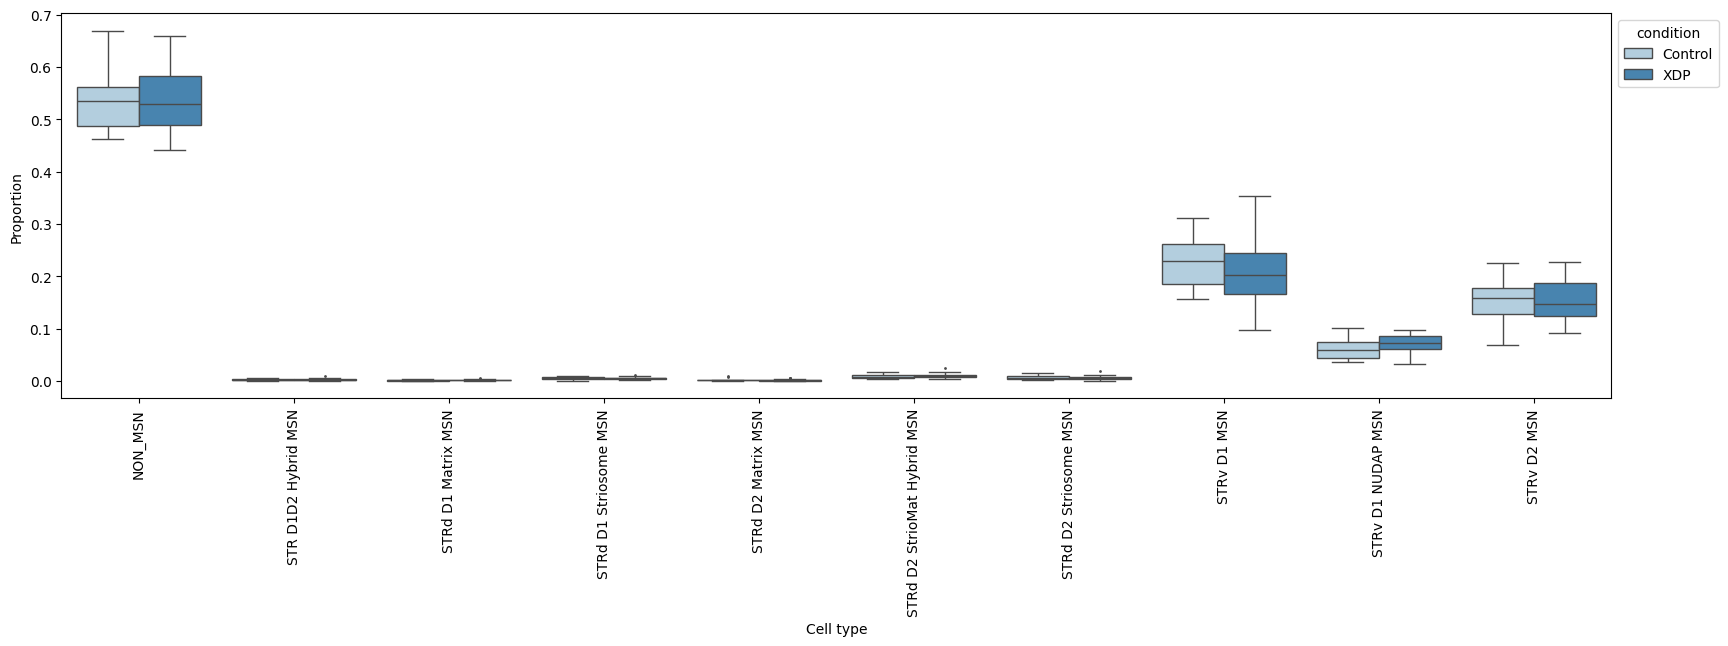

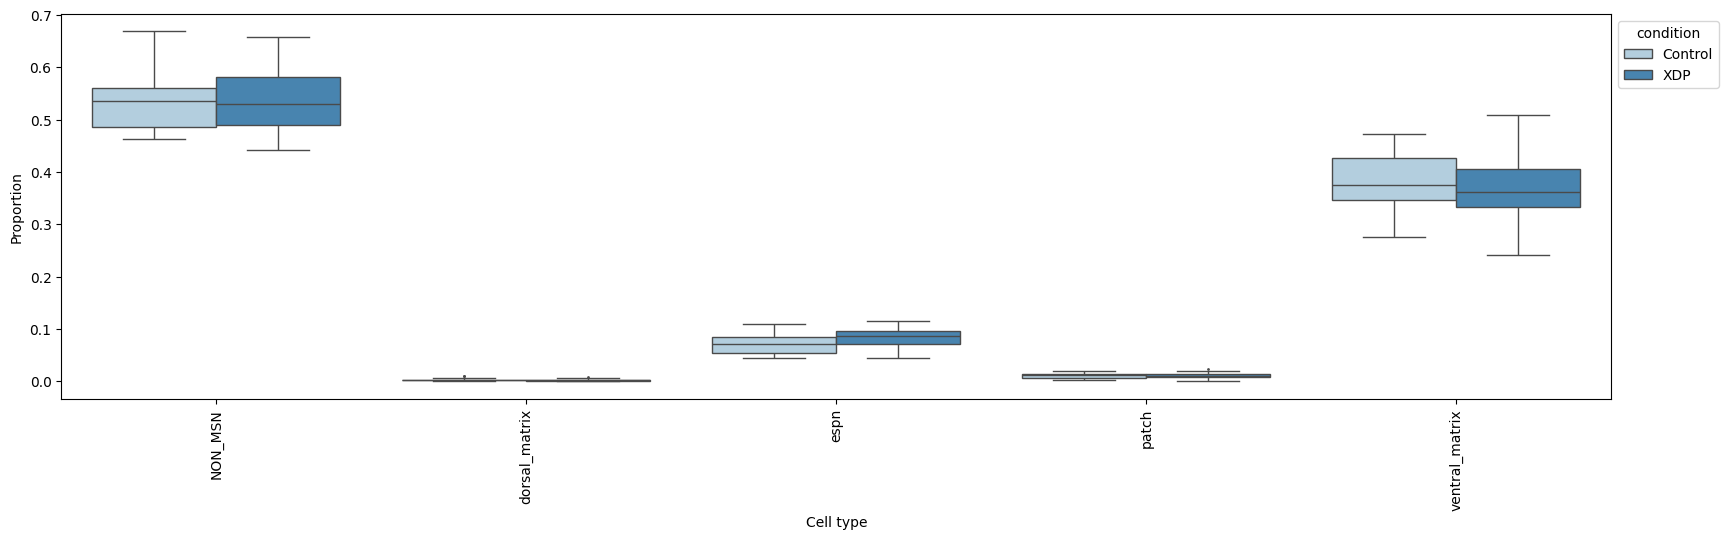

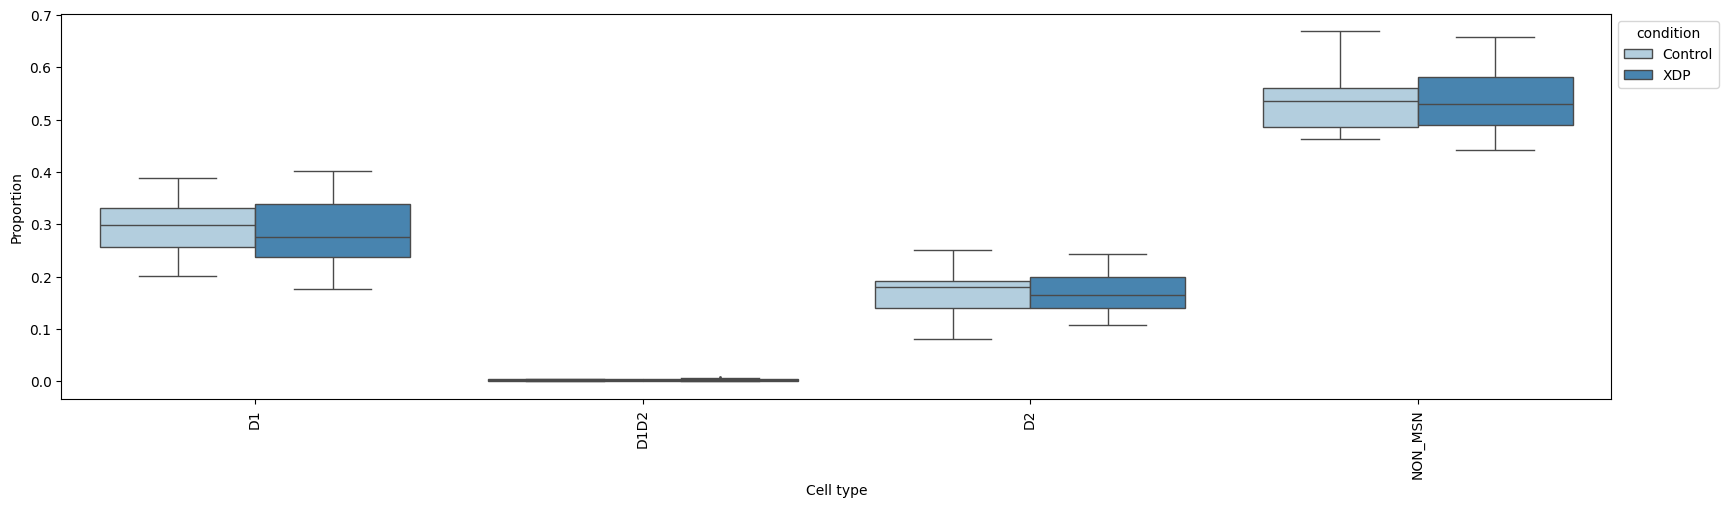

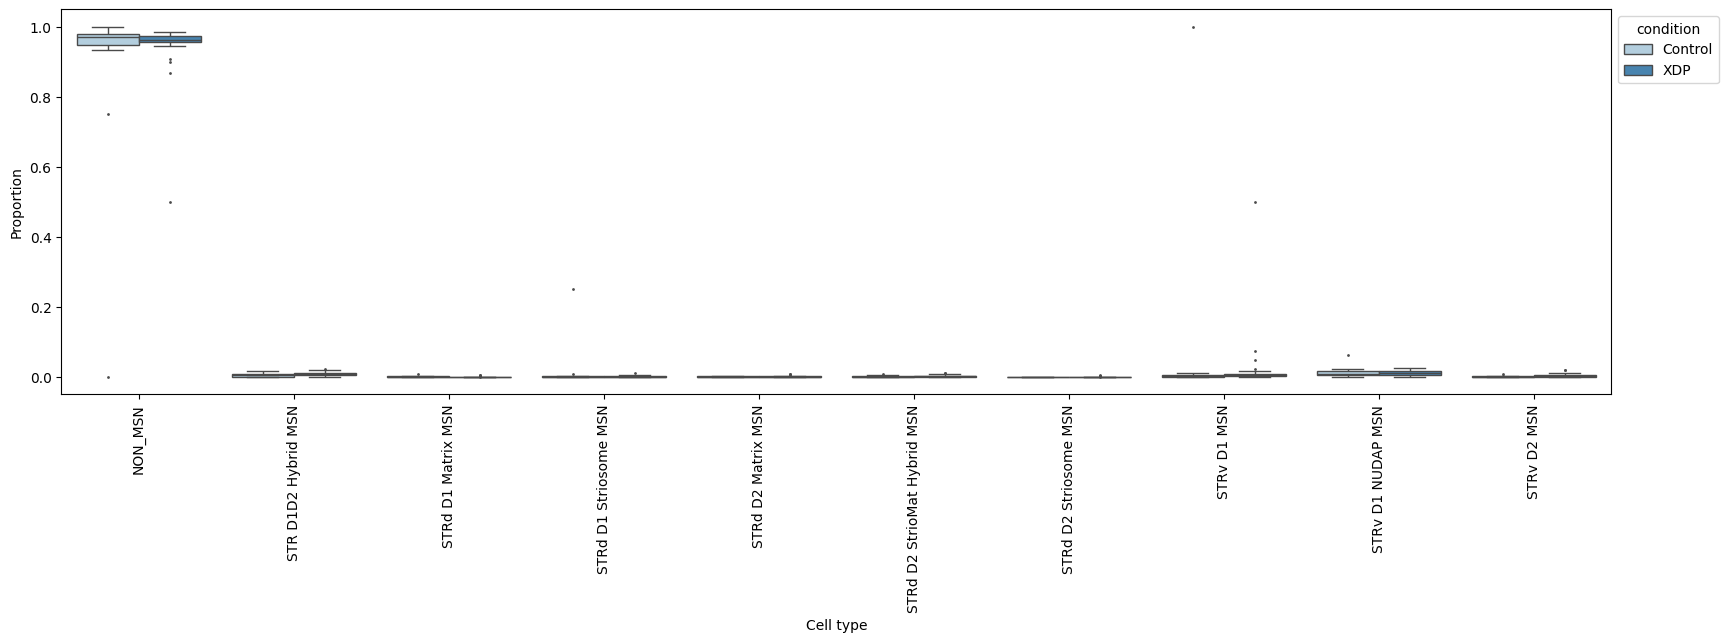

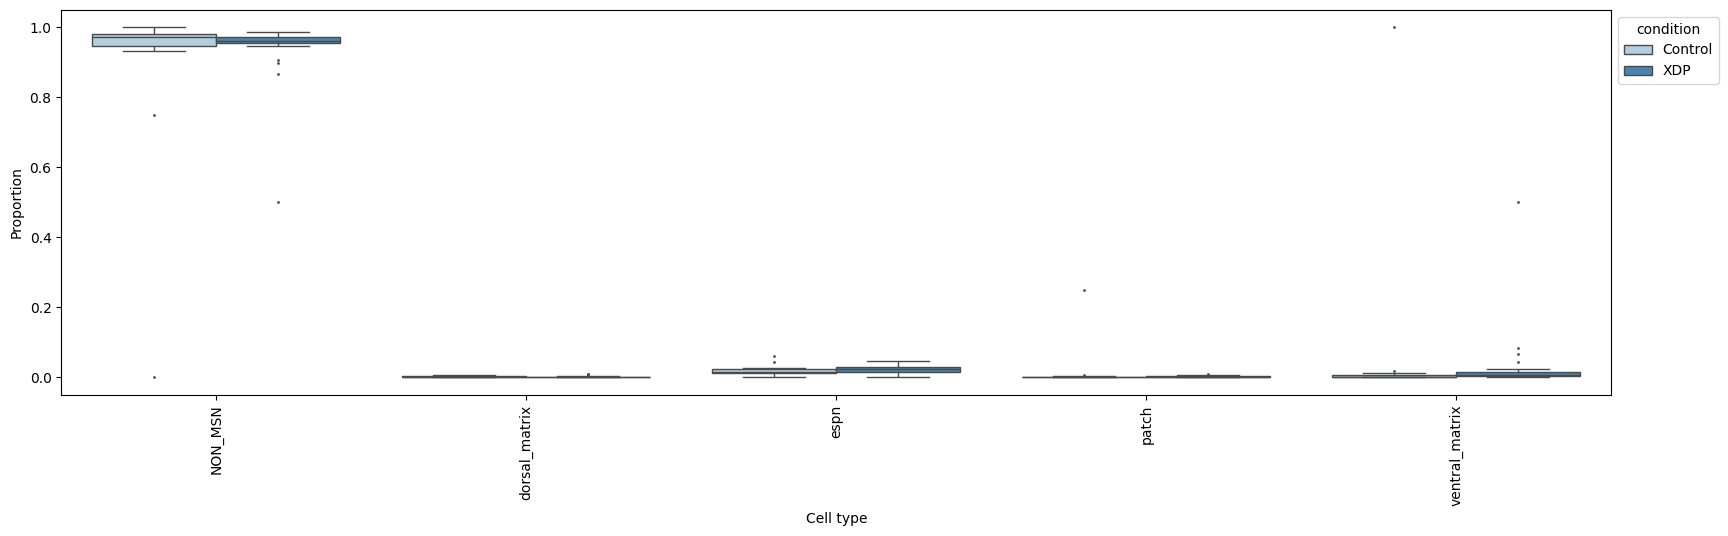

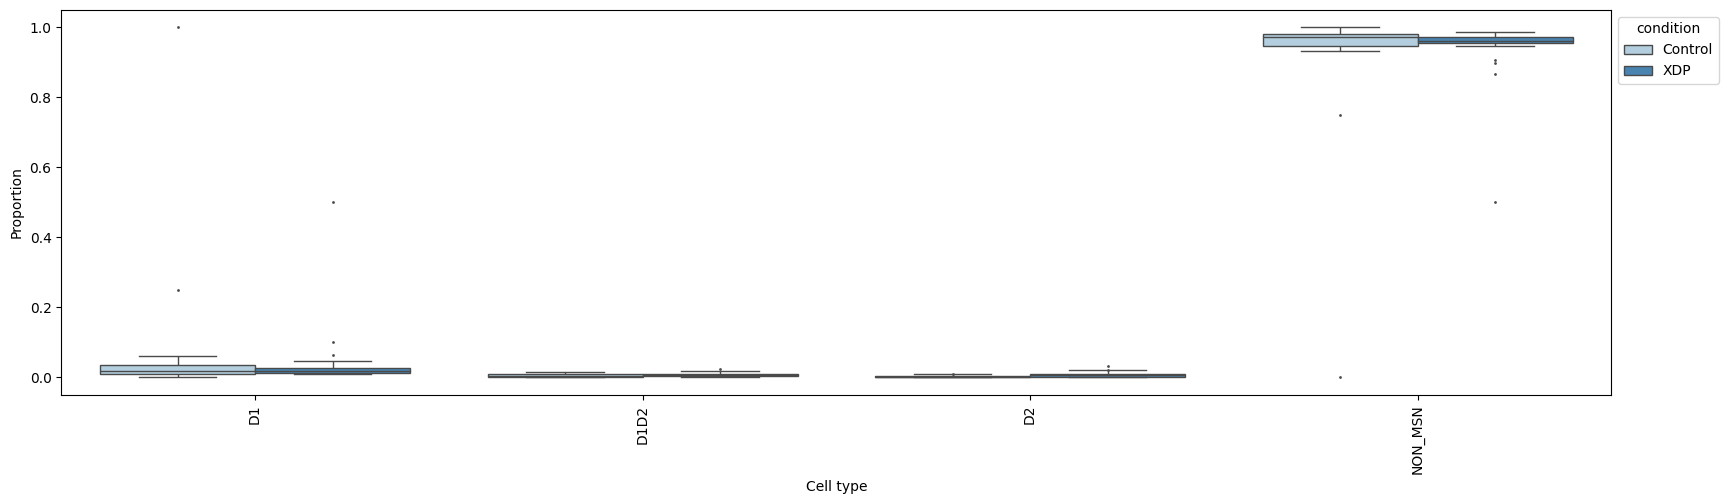

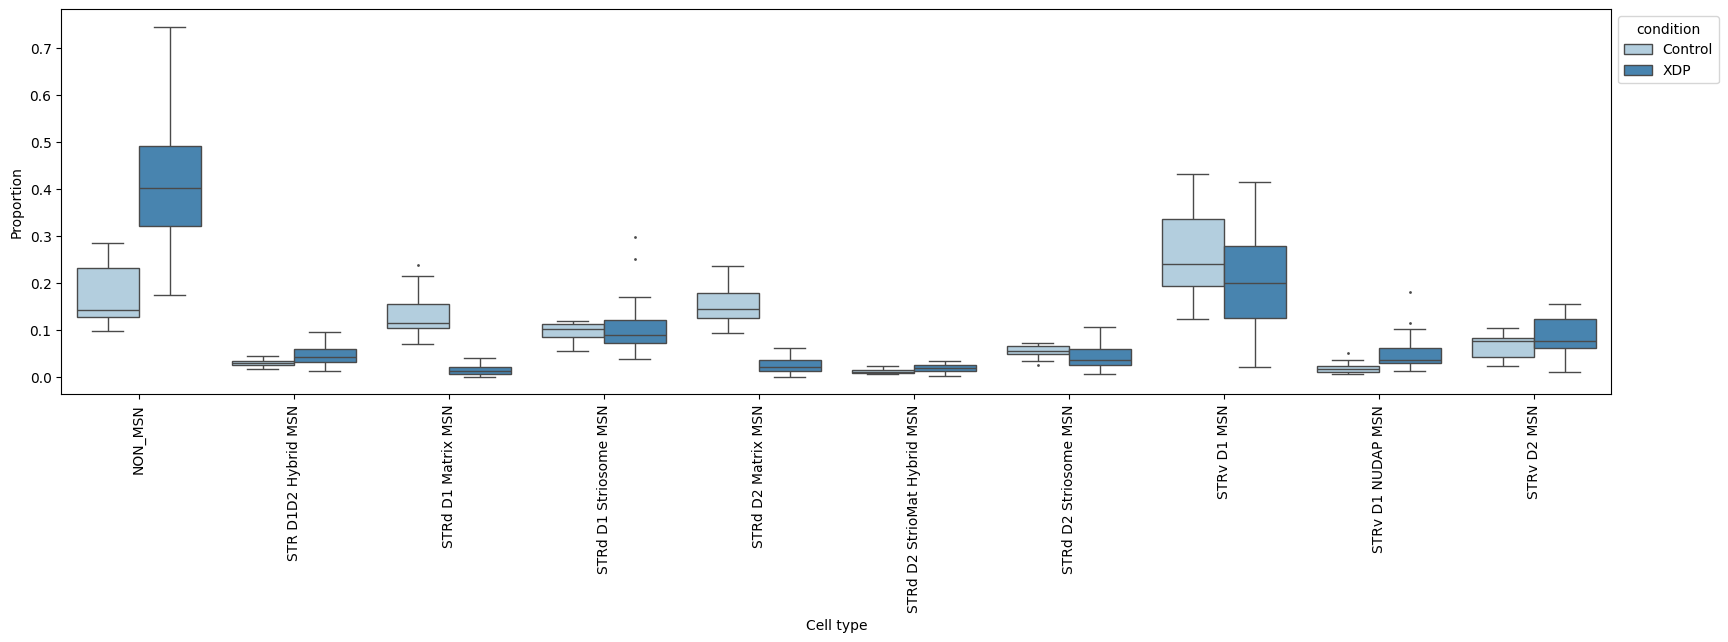

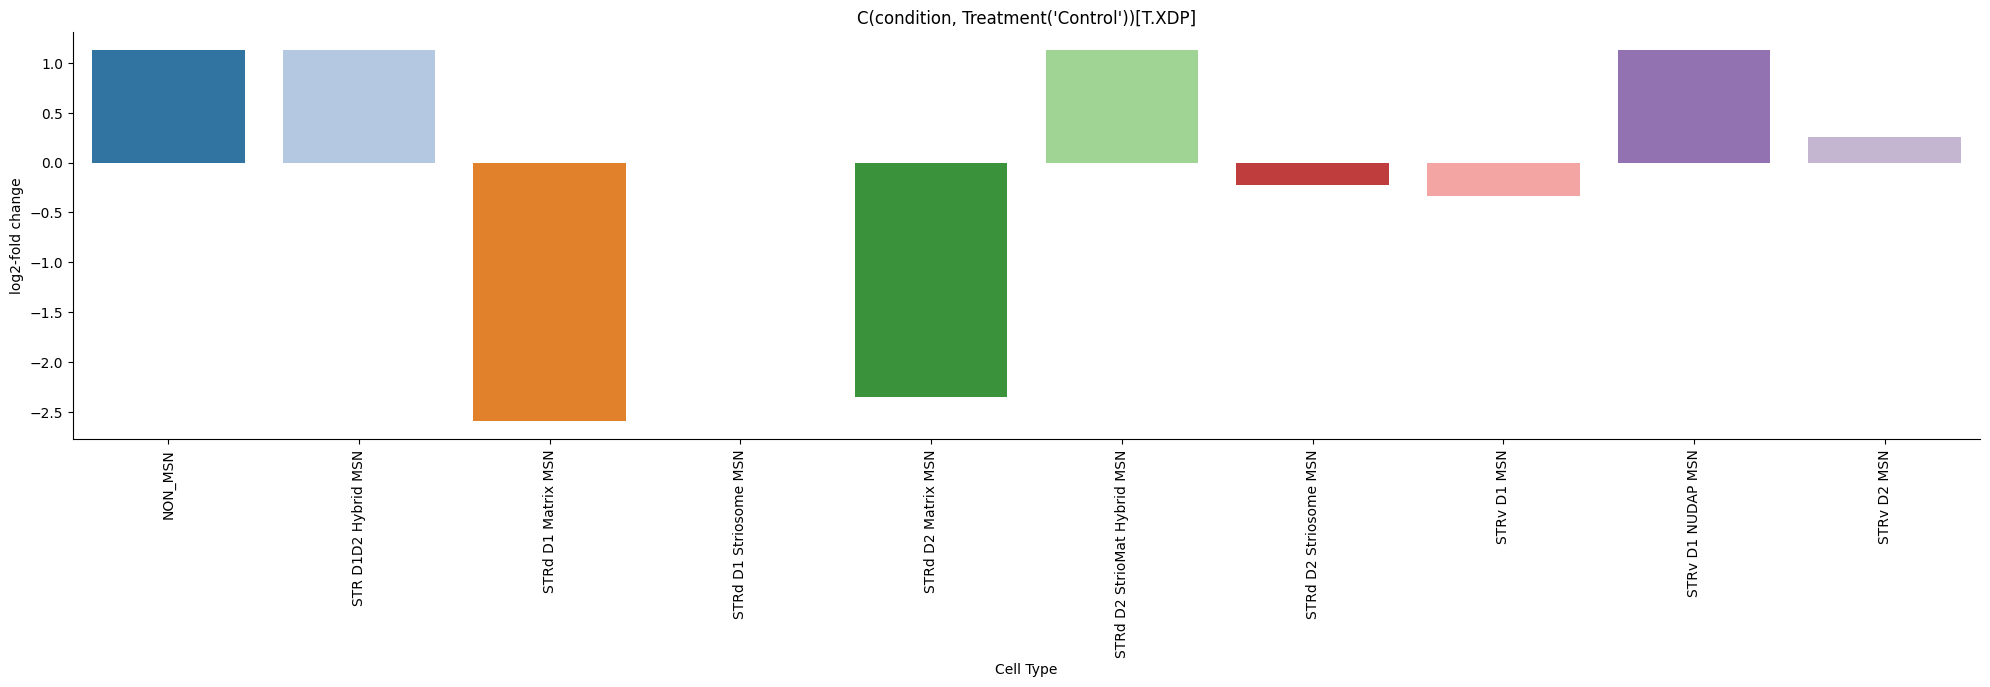

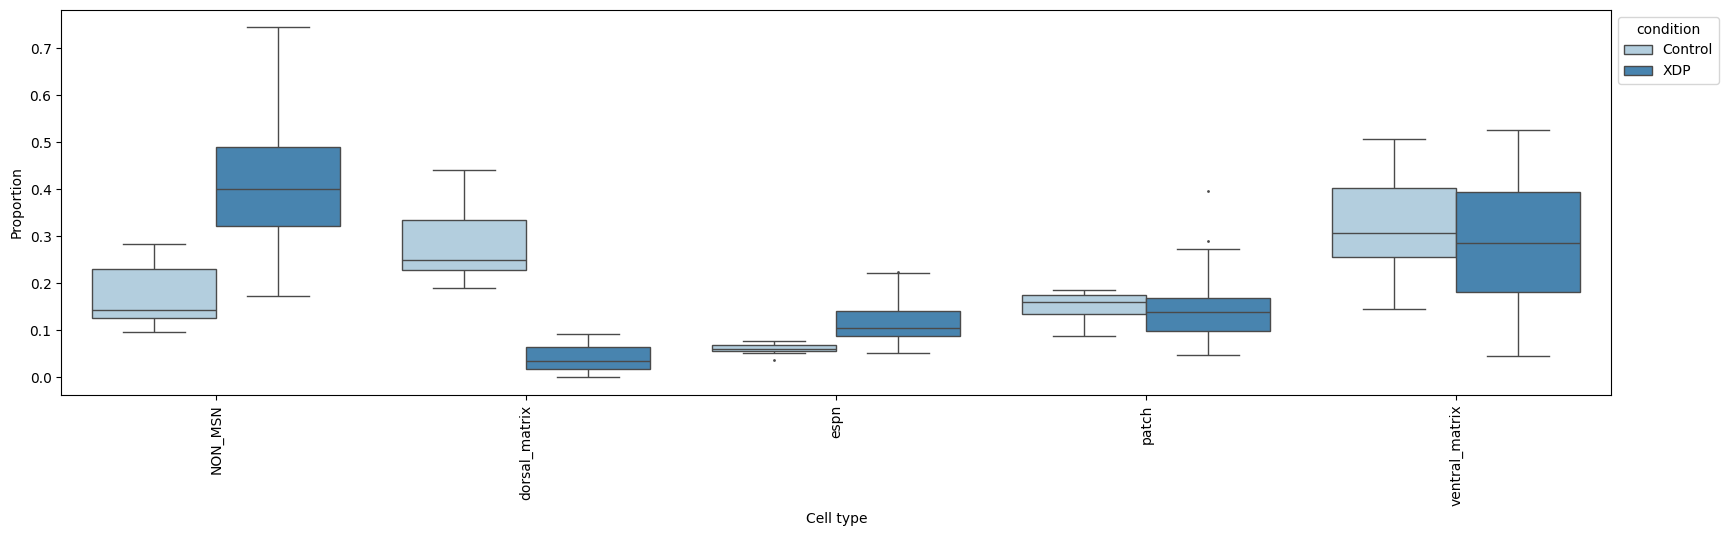

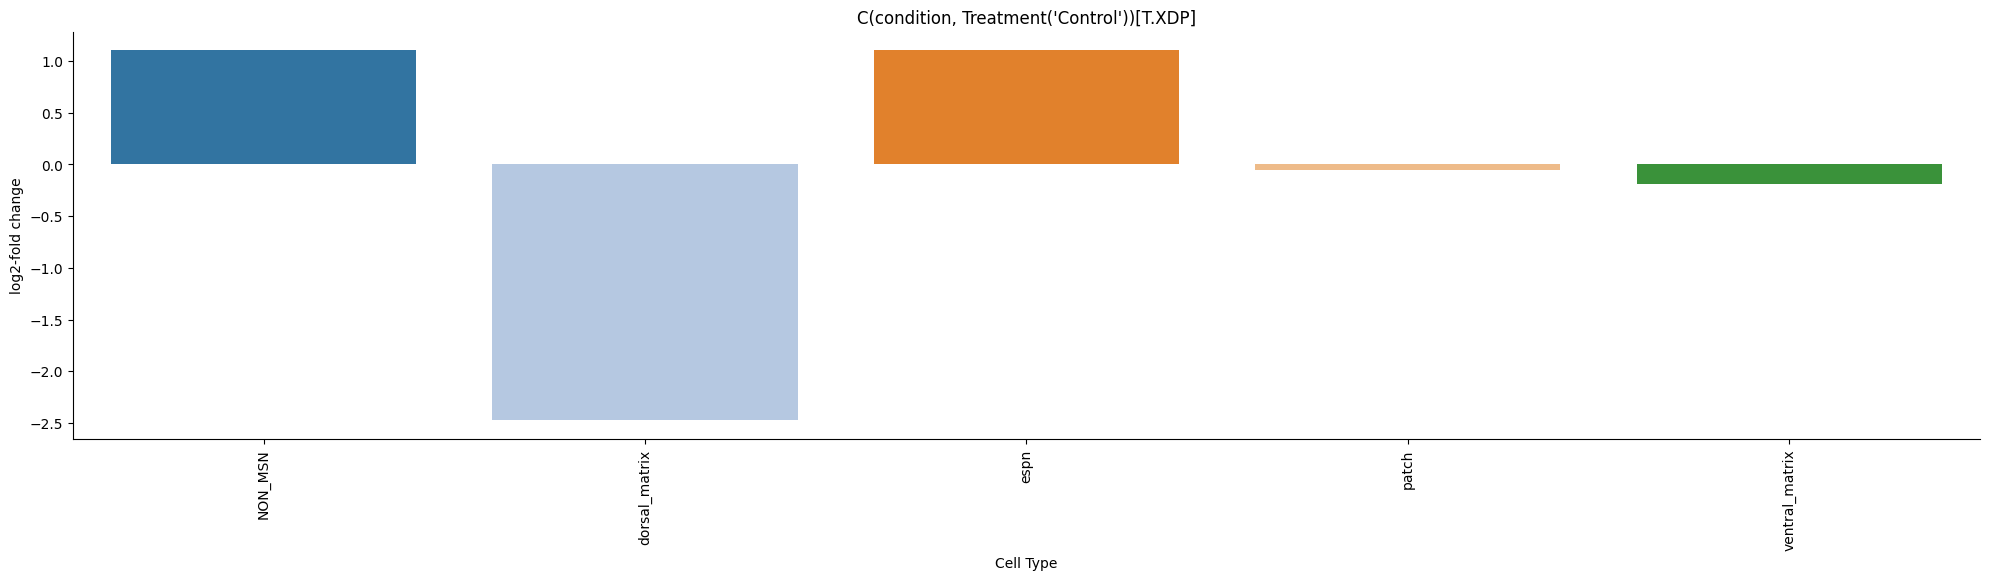

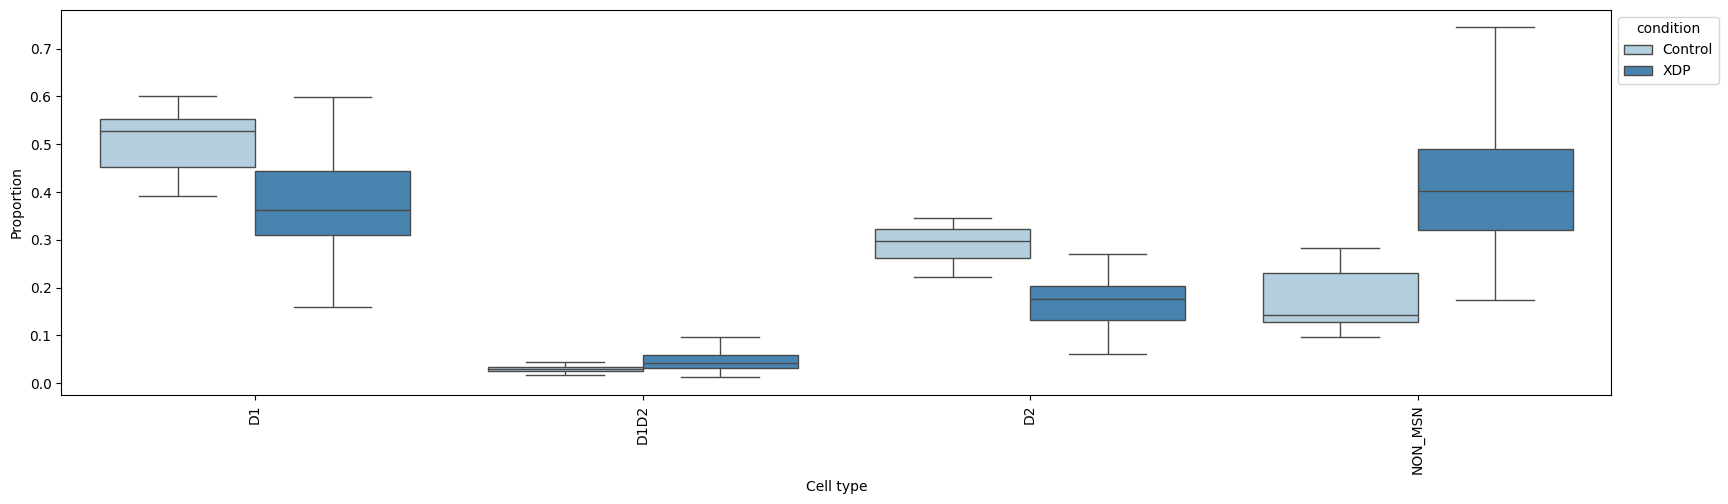

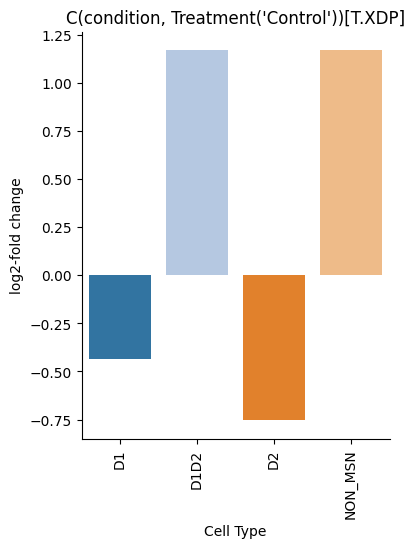

In [39]:
df = run_scCODA_for_NucSeq_dataset(
    adata_n, 
    subfolder_save="only_neurons", 
    LEVELS_ANNOTATION=LEVELS_ANNOTATIOn_ONLY_NEURONS, 
    CONTRAST_VARIABLE=CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION=COV_TO_BRING_TO_AGGREGATED_VERSION, 
    SAMPLE_VARIABLE=SAMPLE_VARIABLE, SAVE_FOLDER=SAVE_FOLDER, FORMULA=FORMULA, 
    REFERENCE_CT=REFERENCE_CT_ONLY_NEURONS, NUTS_ITERATIONS=NUTS_ITERATIONS,
    tissue_col="tissue",
)


In [ ]:
# df_list = []
# for tissue in adata_n.obs.tissue.unique().tolist():
#     for level_annotation in LEVELS_ANNOTATION:

#         print(tissue, level_annotation)

#         # Samples that miss some vital info
#         bad_samples = [i for cov in [CONTRAST_VARIABLE, *COV_TO_BRING_TO_AGGREGATED_VERSION] for i in adata_n.obs[adata_n.obs[cov].isna()][SAMPLE_VARIABLE].unique().tolist()]

#         # Filter
#         adata_sub = adata_n[
#                 (adata_n.obs.tissue == tissue) & 
#                 (~ adata_n.obs[SAMPLE_VARIABLE].isin(bad_samples))
#             ].to_memory().copy()
        
#         # Save folder
#         save_folder = f"{SAVE_FOLDER}/only_neurons/{tissue}/{level_annotation}"
#         os.makedirs(save_folder, exist_ok=True)

#         sccoda, mdata, merged_df = run_scCODA(adata_sub, level_annotation, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, NUTS_ITERATIONS=NUTS_ITERATIONS)

#         merged_df["tissue"] = tissue
#         merged_df["annotation"] = level_annotation

#         df_list.append(merged_df)        

#     #     break
#     # break

# df = pd.concat(df_list)
# df.to_csv(f"{SAVE_FOLDER}/only_neurons/merged_df.csv", index=False)

# By zones

---
---
---

In [77]:
results = pd.DataFrame(sccoda.credible_effects(
    # P_inclusion(cell_type, constion) = number beta_constion > 0.001 / tot betas
    # which is a good thr for P_inclussion?
    # take thr that make the FDR selected
    mdata,
    est_fdr=0.05, # FDR step finds the optimal threshold of P_inclusion automatically
)).rename(columns={"Final Parameter": "is_significant"})
results = results.reset_index()
results['Covariate'] = results["Covariate"].str.extract(r'\[T\.(.*?)\]')[0]
#display(results)

#intercept_df = sccoda.get_intercept_df(mdata)
effect_df = sccoda.get_effect_df(mdata)
effect_df = effect_df.reset_index()
effect_df['Covariate'] = effect_df["Covariate"].str.extract(r'T\.(.*)$')[0]
#display(effect_df)

merged_df = effect_df.merge(
    results, 
    how='inner',        
    validate="one_to_one"
)
merged_df
#merged_df[(merged_df["Covariate"] == CONTRAST_STIM) & (merged_df["is_significant"])]

,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
0,XDP,Astro-Epen,0.000000,-0.169,0.196,0.062,0.372,351.725214,0.091117,False
1,XDP,CN CGE GABA,0.000000,-0.109,0.254,0.070,0.416,283.114165,0.091117,False
2,XDP,CN GABA-Glut,0.000000,-0.342,0.258,0.110,0.470,14.095424,0.091117,False
3,XDP,CN LGE GABA,0.000000,-0.127,0.115,0.041,0.344,971.508704,0.091117,False
4,XDP,CN MGE GABA,0.000000,-0.228,0.102,0.057,0.344,501.122322,0.091117,False
5,XDP,Cx GABA,0.000000,-0.199,0.398,0.119,0.504,17.354472,0.091117,False
6,XDP,F M GABA,0.000000,-0.205,0.156,0.060,0.395,218.732654,0.091117,False
7,XDP,F M Glut,0.000000,0.000,0.000,0.000,0.000,24.115390,0.091117,False
8,XDP,Immune,0.000000,-0.205,0.213,0.070,0.393,129.651519,0.091117,False
9,XDP,M Dopa,0.000000,-0.347,0.285,0.114,0.484,11.844341,0.091117,False


In [ ]:
summary = sccoda.summary(mdata,extended=True)
print(summary)

                                          Compositional Analysis summary                                           
┌────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────┐
│ Name                                   │ Value                                                                  │
├────────────────────────────────────────┼────────────────────────────────────────────────────────────────────────┤
│ Data                                   │ Data: 44 samples, 12 cell types                                        │
│ Reference cell type                    │ F M Glut                                                               │
│ Formula                                │ C(condition, Treatment('Control')) + sex                               │
│ Reference index                        │ 7                                                                      │
│ Spike-and-slab threshold               │ 0.990                                                                  │
│ Spike-and-slab threshold               │ 0.990                                                                  │
│ MCMC Sampling                          │ Sampled 1000 chain states (500 burnin samples)                         │
│ Acceptance rate                        │ 89.2%                                                                  │
└────────────────────────────────────────┴────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                           │
│ Class_name                                                                                                      │
│ Astro-Epen         2.279        2.055   2.507  0.123     330.198                                                │
│ CN CGE GABA        2.062        1.846   2.300  0.121     265.786                                                │
│ CN GABA-Glut      -0.938       -1.308  -0.534  0.207      13.233                                                │
│ CN LGE GABA        3.295        3.127   3.523  0.104     912.048                                                │
│ CN MGE GABA        2.633        2.434   2.864  0.119     470.452                                                │
│ Cx GABA           -0.730       -1.095  -0.338  0.205      16.292                                                │
│ F M GABA           1.804        1.599   2.041  0.123     205.345                                                │
│ F M Glut          -0.401       -0.626  -0.114  0.136      22.639                                                │
│ Immune             1.281        1.013   1.535  0.138     121.716                                                │
│ M Dopa            -1.112       -1.499  -0.742  0.207      11.119                                                │
│ OPC-Oligo          3.201        2.967   3.426  0.124     830.222                                                │
│ Vascular          -0.177       -0.501   0.183  0.190      28.324                                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                       Final Parameter  Expected Sample  log2-fold change        │
│ Covariate                               Cell Type                                                               │
│ C(condition, Treatment('Control'))T.XDP Astro-Epen         0.000           351.725            0.091             │
│                                         CN CGE GABA        0.000           283.114            0.091             │
│                                         CN GABA-Glut       0.000            14.095            0.091             │
│                                         CN LGE GABA        0.000           971.509            0.091             │
│                                         CN MGE GABA        0.000           501.122            0.091             │
│                                         Cx GABA            0.000            17.354            0.091             │
│                                         F M GABA           0.000           218.733            0.091             │
│                                         F M Glut           0.000            24.115            0.091             │
│                                         Immune             0.000           129.652            0.091             │
│                                         M Dopa             0.000            11.844            0.091             │
│                                         OPC-Oligo         -0.272           673.941           -0.301             │
│                                         Vascular           0.000            30.170            0.091             │
│ sexT.M                                  Astro-Epen         0.000           301.091           -0.133             │
│                                         CN CGE GABA        0.000           242.357           -0.133             │
│                                         CN GABA-Glut       0.000            12.066           -0.133             │
│                                         CN LGE GABA        0.000           831.652           -0.133             │
│                                         CN MGE GABA        0.000           428.982           -0.133             │
│                                         Cx GABA            0.000            14.856           -0.133             │
│                                         F M GABA           0.000           187.244           -0.133             │
│                                         F M Glut           0.000            20.644           -0.133             │
│                                         Immune             0.000           110.987           -0.133             │
│                                         M Dopa             0.000            10.139           -0.133             │
│                                         OPC-Oligo          0.319          1041.529            0.327             │
│                                         Vascular           0.000            25.827           -0.133             │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                       HDI 3%  HDI 97%   SD   Inclusion probability              │
│ Covariate                               Cell Type                                                               │
│ C(condition, Treatment('Control'))T.XDP Astro-Epen    -0.169   0.196  0.062         0.372                       │
│                                         CN CGE GABA   -0.109   0.254  0.070         0.416                       │
│                                         CN GABA-Glut  -0.342   0.258  0.110         0.470                       │
│                                         CN LGE GABA   -0.127   0.115  0.041         0.344                       │
│                                         CN MGE GABA   -0.228   0.102  0.057         0.344                       │
│                                         Cx GABA       -0.199   0.398  0.119         0.504                       │
│                                         F M GABA      -0.205   0.156  0.060         0.395                       │
│                                         F M Glut       0.000   0.000  0.000         0.000                       │
│                                         Immune        -0.205   0.213  0.070         0.393                       │
│                                         M Dopa        -0.347   0.285  0.114         0.484                       │
│                                         OPC-Oligo     -0.431  -0.097  0.091         0.994                       │
│                                         Vascular      -0.272   0.300  0.106         0.453                       │
│ sexT.M                                  Astro-Epen    -0.143   0.352  0.096         0.423                       │
│                                         CN CGE GABA   -0.230   0.233  0.076         0.369                       │
│                                         CN GABA-Glut  -0.477   0.401  0.155         0.493                       │
│                                         CN LGE GABA   -0.215   0.097  0.063         0.367                       │
│                                         CN MGE GABA   -0.288   0.102  0.081         0.430                       │
│                                         Cx GABA       -0.402   0.439  0.155         0.492                       │
│                                         F M GABA      -0.250   0.248  0.081         0.409                       │
│                                         F M Glut       0.000   0.000  0.000         0.000                       │
│                                         Immune        -0.331   0.250  0.096         0.391                       │
│                                         M Dopa        -0.365   0.436  0.148         0.473                       │
│                                         OPC-Oligo      0.105   0.533  0.120         0.990                       │
│                                         Vascular      -0.265   0.475  0.144         0.430                       │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

None


/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


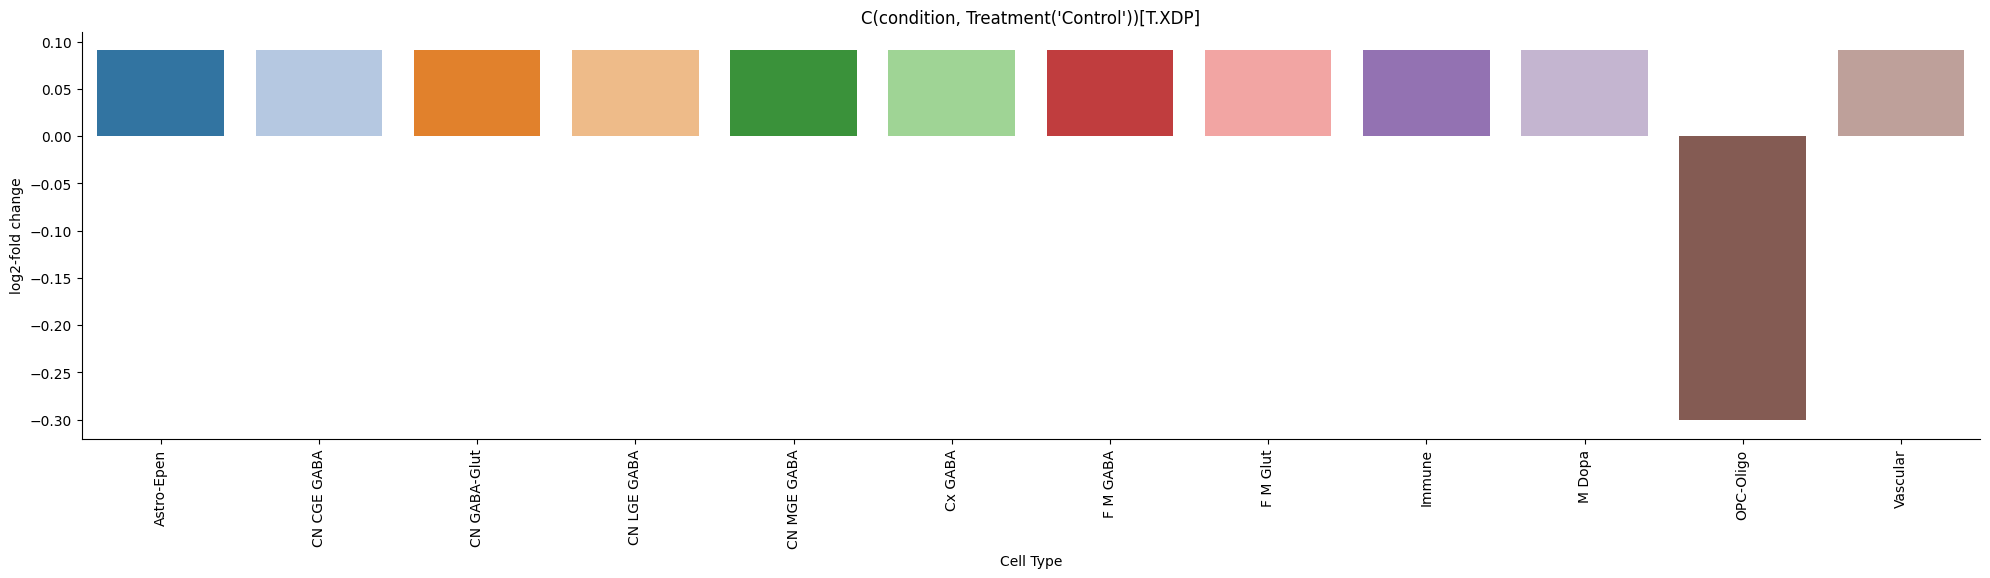

In [73]:
sccoda.plot_effects_barplot(
    mdata,
    covariates=[CONTRAST_VARIABLE],
    figsize=(5,20),
    parameter="log2-fold change",
    plot_zero_cell_type=False
)

In [33]:
a = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STR_D1_Matrix_MSN.h5ad")
a.obs.columns

AnnData object with n_obs × n_vars = 60598 × 37905
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'logumi', 'cb_index', 'percent.

In [34]:
a.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX',
       'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES',
       'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic',
       'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal',
       'frac_contamination', 'experiment', 'donor_external_id',
       'is_primary_data', 'Neighborhood_label', 'Neighborhood_name',
       'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name',
       'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name',
       'Subclass_bootstrapping_probability', 'Group_label', 'Group_name',
       'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name',
       'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id',
       'n_counts', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.8',
       'seurat_clusters', 'library', 'donor', 'unique_cell_ID', 'AK_celltype',
       'RNA_snn_res.0.2', 'cb', 'clusters', 'num_db